# 🦠 WannaCry como Pandemia de Red — Análisis Clínico SIR/SEIR

Utilizamos el grafo de red como *tejido huésped* y los parámetros β/γ
calibrados desde el PCAP real del ataque (15/05/2017).

### Métricas clínicas que calcularemos
| Métrica | Analogía médica |
|---|---|
| Curva S-I-R(t) | Evolución de la pandemia en la población |
| Pico de infección | Punto crítico de saturación hospitalaria |
| Tiempo al pico | Velocidad de propagación del brote |
| Tasa de ataque final | % de población que fue infectada al final |
| R(t) efectivo | Número reproductivo a lo largo del tiempo |
| Velocidad dI/dt | Aceleración / desaceleración del brote |
| Nodos super-spreaders | Pacientes de alta transmisibilidad (hubs) |
| Efecto del kill-switch | Impacto de la vacuna / contención |

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import seaborn as sns
import networkx as nx
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path("..").resolve()))
from src.simulation.epidemic_models import run_sir_simulation, run_seir_simulation

ROOT      = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
FIGURES   = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Parametros reales calibrados desde PCAP WannaCry (15/05/2017)
with open(PROCESSED / "wannacry_pcap_sir_metadata.json") as f:
    meta = json.load(f)

BETA_BASE  = meta["beta_from_pcap"]   # 0.9223  — intensidad SMB/445 real
GAMMA_BASE = meta["baseline_gamma"]   # 0.04    — tasa recuperacion base
BETA_KS    = meta["contained_beta"]   # 0.08    — despues del kill-switch
GAMMA_KS   = meta["contained_gamma"]  # 0.22    — parcheo acelerado
R0_BASE    = round(BETA_BASE / GAMMA_BASE, 2)
R0_KS      = round(BETA_KS   / GAMMA_KS,   2)

print(f"Parametros WannaCry (PCAP real)")
print(f"  Beta sin contencion  : {BETA_BASE}  |  Gamma: {GAMMA_BASE}  |  R0={R0_BASE}")
print(f"  Beta kill-switch     : {BETA_KS}   |  Gamma: {GAMMA_KS}  |  R0={R0_KS}")

Parametros WannaCry (PCAP real)
  Beta sin contencion  : 0.9223  |  Gamma: 0.04  |  R0=23.06
  Beta kill-switch     : 0.08   |  Gamma: 0.22  |  R0=0.36


## 🌐 Construcción del Grafo de Red
Red libre de escala **Barabási-Albert** (300 nodos, m=3).
Este tipo de red replica la topología de Internet: pocos hubs muy conectados,
mayoría de nodos con grado bajo — exactamente como WannaCry la encontró.

In [2]:
N     = 300
SEED  = 42
STEPS = 100

G_raw = nx.barabasi_albert_graph(N, 3, seed=SEED)
G     = nx.relabel_nodes(G_raw, {n: f"Host_{n:03d}" for n in G_raw.nodes()})
INIT  = ["Host_004"]   # Paciente cero

degrees = dict(G.degree())
deg_vals = np.array(list(degrees.values()))

print(f"Nodos : {G.number_of_nodes()}")
print(f"Aristas: {G.number_of_edges()}")
print(f"Grado promedio : {deg_vals.mean():.2f}")
print(f"Grado maximo   : {deg_vals.max()}  <- super-spreader")
print(f"Densidad       : {nx.density(G):.4f}")

# Top 5 hubs (super-spreaders)
top5 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\nTop 5 super-spreaders:")
for node, deg in top5:
    print(f"  {node}: grado {deg}")

Nodos : 300
Aristas: 891
Grado promedio : 5.94
Grado maximo   : 49  <- super-spreader
Densidad       : 0.0199

Top 5 super-spreaders:
  Host_004: grado 49
  Host_005: grado 46
  Host_006: grado 44
  Host_007: grado 41
  Host_000: grado 34


## 🔬 Simulaciones SIR — 3 Escenarios Clínicos
| Escenario | Descripción clínica |
|---|---|
| **Sin contención** | Red sin parches, WannaCry libre (β=0.9223) |
| **Kill-Switch activado** | Marcus Hutchins detiene la propagación (β cae a 0.08) |
| **SEIR** | Incluye período de incubación latente (E) antes de infectar |

In [3]:
# Escenario 1: Sin contencion
res_libre = run_sir_simulation(G, beta=BETA_BASE, gamma=GAMMA_BASE,
                               steps=STEPS, initial_infected=INIT)

# Escenario 2: Kill-Switch (parametros post-contencion)
res_ks    = run_sir_simulation(G, beta=BETA_KS, gamma=GAMMA_KS,
                               steps=STEPS, initial_infected=INIT)

# Escenario 3: SEIR (sigma = tasa de incubacion -> infectado, aprox 1/2 dias)
res_seir  = run_seir_simulation(G, beta=BETA_BASE, sigma=0.5, gamma=GAMMA_BASE,
                                steps=STEPS, initial_infected=INIT)

df_libre = res_libre.history.copy()
df_ks    = res_ks.history.copy()
df_seir  = res_seir.history.copy()

# Pico de infeccion
pico_libre = df_libre.loc[df_libre["I"].idxmax()]
pico_ks    = df_ks.loc[df_ks["I"].idxmax()]
pico_seir  = df_seir.loc[df_seir["I"].idxmax()]

print(f"Escenario Sin contencion:")
print(f"  Pico: {pico_libre['I']} infectados ({pico_libre['I']/N:.1%}) en paso {int(pico_libre['step'])}")
print(f"  Tasa ataque final: {df_libre.iloc[-1]['R']/N:.1%}")
print(f"\nEscenario Kill-Switch:")
print(f"  Pico: {pico_ks['I']} infectados ({pico_ks['I']/N:.1%}) en paso {int(pico_ks['step'])}")
print(f"  Tasa ataque final: {df_ks.iloc[-1]['R']/N:.1%}")
print(f"\nEscenario SEIR:")
print(f"  Pico: {pico_seir['I']} infectados ({pico_seir['I']/N:.1%}) en paso {int(pico_seir['step'])}")

Escenario Sin contencion:


  Pico: 290 infectados (96.7%) en paso 3
  Tasa ataque final: 97.0%

Escenario Kill-Switch:
  Pico: 70 infectados (23.3%) en paso 12
  Tasa ataque final: 68.7%

Escenario SEIR:
  Pico: 260 infectados (86.7%) en paso 9


## 📉 R(t) — Número Reproductivo Efectivo en el Tiempo
R(t) = R₀ × (S(t)/N): cuántos nodos infecta cada nodo infectado en ese momento.
- **R(t) > 1** → brote creciendo (epidemia activa)
- **R(t) = 1** → punto de inflexión
- **R(t) < 1** → brote bajo control

In [4]:
def calc_rt(df, beta, gamma, N):
    """R(t) = beta/gamma * S(t)/N"""
    return (beta / gamma) * (df["S"] / N)

df_libre["Rt"] = calc_rt(df_libre, BETA_BASE, GAMMA_BASE, N)
df_ks["Rt"]    = calc_rt(df_ks,    BETA_KS,   GAMMA_KS,   N)
df_seir["Rt"]  = calc_rt(df_seir,  BETA_BASE, GAMMA_BASE,  N)

In [5]:
df_libre["dI"] = df_libre["I"].diff().fillna(0)
df_ks["dI"]    = df_ks["I"].diff().fillna(0)
df_seir["dI"]  = df_seir["I"].diff().fillna(0)

## 📊 Panel Clínico Completo

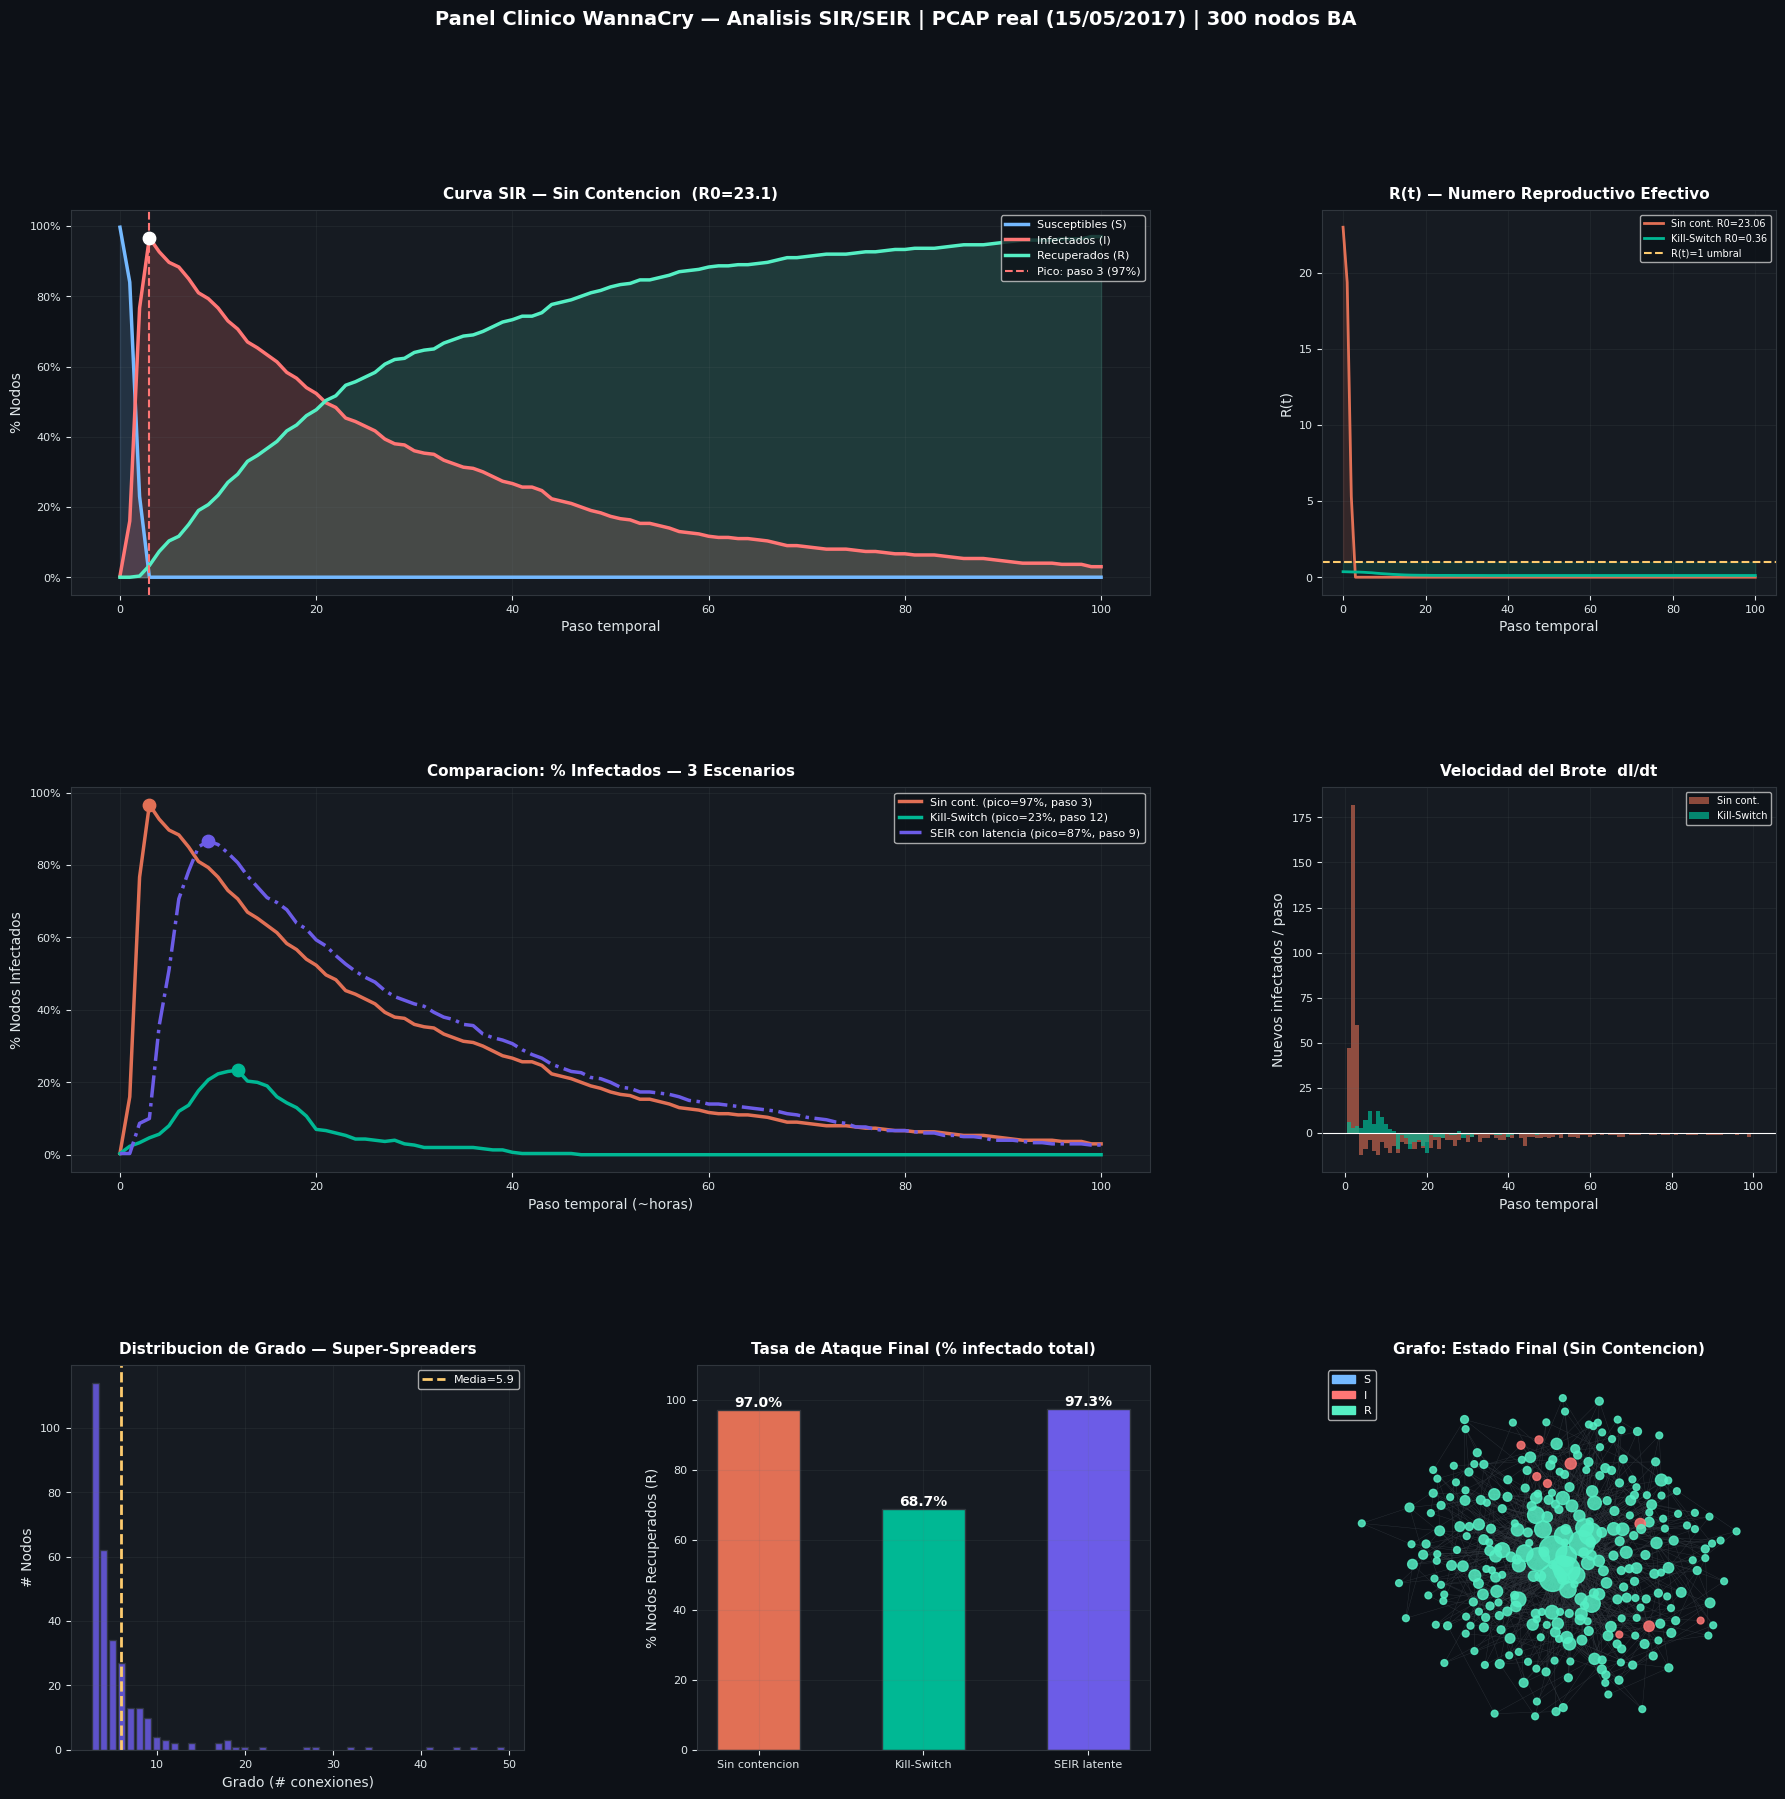

Figura guardada: reports/figures/07_sir_panel_clinico.png


In [6]:
BG   = "#0D1117"
CARD = "#161B22"
EDGE = "#30363D"
C1, C2, C3 = "#E17055", "#00B894", "#6C5CE7"   # libre, kill-switch, seir
CS, CI, CR, CE = "#74B9FF","#FF7675","#55EFC4","#FDCB6E"

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

def style_ax(ax, title):
    ax.set_facecolor(CARD)
    ax.set_title(title, color="white", fontsize=11, fontweight="bold", pad=8)
    ax.tick_params(colors="#DFE6E9", labelsize=8)
    ax.spines[:].set_edgecolor(EDGE)
    ax.grid(alpha=0.12, color="#636e72")

# ── 1. Curvas SIR principales (sin contencion) ────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1, "Curva SIR — Sin Contencion  (R0={:.1f})".format(R0_BASE))
t = df_libre["step"]
ax1.fill_between(t, df_libre["S"]/N*100, alpha=0.15, color=CS)
ax1.fill_between(t, df_libre["I"]/N*100, alpha=0.20, color=CI)
ax1.fill_between(t, df_libre["R"]/N*100, alpha=0.15, color=CR)
ax1.plot(t, df_libre["S"]/N*100, color=CS, lw=2.5, label="Susceptibles (S)")
ax1.plot(t, df_libre["I"]/N*100, color=CI, lw=2.5, label="Infectados (I)")
ax1.plot(t, df_libre["R"]/N*100, color=CR, lw=2.5, label="Recuperados (R)")
ax1.axvline(pico_libre["step"], color=CI, ls="--", lw=1.5,
            label=f"Pico: paso {int(pico_libre['step'])} ({pico_libre['I']/N:.0%})")
ax1.scatter(pico_libre["step"], pico_libre["I"]/N*100, color="white", s=80, zorder=6)
ax1.set_xlabel("Paso temporal", color="#DFE6E9")
ax1.set_ylabel("% Nodos", color="#DFE6E9")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(fontsize=8, facecolor=BG, labelcolor="white", loc="upper right")

# ── 2. R(t) ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2, "R(t) — Numero Reproductivo Efectivo")
ax2.plot(df_libre["step"], df_libre["Rt"], color=C1, lw=2, label=f"Sin cont. R0={R0_BASE}")
ax2.plot(df_ks["step"],    df_ks["Rt"],    color=C2, lw=2, label=f"Kill-Switch R0={R0_KS}")
ax2.axhline(1.0, color="#FDCB6E", ls="--", lw=1.5, label="R(t)=1 umbral")
ax2.fill_between(df_libre["step"], df_libre["Rt"], 1,
                 where=df_libre["Rt"]>1, alpha=0.15, color=C1)
ax2.fill_between(df_ks["step"],   df_ks["Rt"],   1,
                 where=df_ks["Rt"]<1, alpha=0.15, color=C2)
ax2.set_xlabel("Paso temporal", color="#DFE6E9")
ax2.set_ylabel("R(t)", color="#DFE6E9")
ax2.legend(fontsize=7, facecolor=BG, labelcolor="white")

# ── 3. Comparacion 3 escenarios — % Infectados ───────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
style_ax(ax3, "Comparacion: % Infectados — 3 Escenarios")
ax3.plot(df_libre["step"], df_libre["I"]/N*100, color=C1, lw=2.5,
         label=f"Sin cont. (pico={pico_libre['I']/N:.0%}, paso {int(pico_libre['step'])})")
ax3.plot(df_ks["step"],   df_ks["I"]/N*100,   color=C2, lw=2.5,
         label=f"Kill-Switch (pico={pico_ks['I']/N:.0%}, paso {int(pico_ks['step'])})")
ax3.plot(df_seir["step"], df_seir["I"]/N*100, color=C3, lw=2.5, ls="-.",
         label=f"SEIR con latencia (pico={pico_seir['I']/N:.0%}, paso {int(pico_seir['step'])})")
for pico, col in [(pico_libre,C1),(pico_ks,C2),(pico_seir,C3)]:
    ax3.scatter(pico["step"], pico["I"]/N*100, color=col, s=80, zorder=6)
ax3.set_xlabel("Paso temporal (~horas)", color="#DFE6E9")
ax3.set_ylabel("% Nodos Infectados", color="#DFE6E9")
ax3.yaxis.set_major_formatter(mtick.PercentFormatter())
ax3.legend(fontsize=8, facecolor=BG, labelcolor="white")

# ── 4. Velocidad dI/dt ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
style_ax(ax4, "Velocidad del Brote  dI/dt")
ax4.bar(df_libre["step"], df_libre["dI"], color=C1, alpha=0.6, width=1, label="Sin cont.")
ax4.bar(df_ks["step"],    df_ks["dI"],    color=C2, alpha=0.7, width=1, label="Kill-Switch")
ax4.axhline(0, color="white", lw=0.8)
ax4.set_xlabel("Paso temporal", color="#DFE6E9")
ax4.set_ylabel("Nuevos infectados / paso", color="#DFE6E9")
ax4.legend(fontsize=7, facecolor=BG, labelcolor="white")

# ── 5. Distribucion de grados (super-spreaders) ──────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
style_ax(ax5, "Distribucion de Grado — Super-Spreaders")
from collections import Counter
deg_count = Counter(deg_vals)
xs = sorted(deg_count.keys())
ys = [deg_count[x] for x in xs]
ax5.bar(xs, ys, color="#6C5CE7", edgecolor=EDGE, alpha=0.85)
ax5.axvline(deg_vals.mean(), color="#FDCB6E", ls="--", lw=2,
            label=f"Media={deg_vals.mean():.1f}")
ax5.set_xlabel("Grado (# conexiones)", color="#DFE6E9")
ax5.set_ylabel("# Nodos", color="#DFE6E9")
ax5.legend(fontsize=8, facecolor=BG, labelcolor="white")

# ── 6. Tasa de ataque final por escenario ────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
style_ax(ax6, "Tasa de Ataque Final (% infectado total)")
escenarios = ["Sin contencion", "Kill-Switch", "SEIR latente"]
tasas = [df_libre.iloc[-1]["R"]/N*100,
         df_ks.iloc[-1]["R"]/N*100,
         df_seir.iloc[-1]["R"]/N*100]
cols_bar = [C1, C2, C3]
bars = ax6.bar(escenarios, tasas, color=cols_bar, edgecolor=EDGE, width=0.5)
for bar, v in zip(bars, tasas):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f"{v:.1f}%", ha="center", color="white", fontsize=10, fontweight="bold")
ax6.set_ylabel("% Nodos Recuperados (R)", color="#DFE6E9")
ax6.set_ylim(0, 110)

# ── 7. Visualizacion del grafo coloreado por estado final ────────────────
ax7 = fig.add_subplot(gs[2, 2])
style_ax(ax7, "Grafo: Estado Final (Sin Contencion)")
final_states = res_libre.node_states
node_colors = []
for n in G.nodes():
    st = final_states.get(n, "S")
    node_colors.append({"S":CS,"I":CI,"R":CR}.get(st, CS))
pos = nx.spring_layout(G, seed=SEED, k=0.3)
node_sizes = [max(15, degrees.get(n,1)*8) for n in G.nodes()]
nx.draw_networkx(G, pos=pos, ax=ax7, with_labels=False,
                 node_color=node_colors, node_size=node_sizes,
                 edge_color="#30363D", width=0.3, alpha=0.85)
from matplotlib.patches import Patch
ax7.legend(handles=[Patch(color=CS,label="S"),
                    Patch(color=CI,label="I"),
                    Patch(color=CR,label="R")],
           fontsize=8, facecolor=BG, labelcolor="white", loc="upper left")
ax7.axis("off")

fig.suptitle(
    "Panel Clinico WannaCry — Analisis SIR/SEIR | PCAP real (15/05/2017) | 300 nodos BA",
    color="white", fontsize=14, fontweight="bold")

plt.savefig(FIGURES / "07_sir_panel_clinico.png",
            dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Figura guardada: reports/figures/07_sir_panel_clinico.png")

## 📋 Resumen de Indicadores Clínicos

In [7]:
final_libre = df_libre.iloc[-1]
final_ks    = df_ks.iloc[-1]
final_seir  = df_seir.iloc[-1]

resumen = pd.DataFrame({
    "Indicador": [
        "R0 base",
        "Pico infeccion (% nodos)",
        "Paso al pico",
        "Tasa ataque final (%R)",
        "Nodos nunca infectados (%S final)",
        "Tiempo R(t)<1 (paso)",
        "Reduccion pico vs sin cont.",
    ],
    "Sin Contencion": [
        f"{R0_BASE}",
        f"{pico_libre['I']/N:.1%}",
        f"paso {int(pico_libre['step'])}",
        f"{final_libre['R']/N:.1%}",
        f"{final_libre['S']/N:.1%}",
        f"paso {int(df_libre[df_libre['Rt']<1]['step'].min()) if (df_libre['Rt']<1).any() else 'nunca'}",
        "—",
    ],
    "Kill-Switch": [
        f"{R0_KS}",
        f"{pico_ks['I']/N:.1%}",
        f"paso {int(pico_ks['step'])}",
        f"{final_ks['R']/N:.1%}",
        f"{final_ks['S']/N:.1%}",
        f"paso {int(df_ks[df_ks['Rt']<1]['step'].min()) if (df_ks['Rt']<1).any() else 'nunca'}",
        f"{(pico_libre['I']-pico_ks['I'])/pico_libre['I']:.1%} menos",
    ],
    "SEIR (latencia)": [
        f"{R0_BASE}",
        f"{pico_seir['I']/N:.1%}",
        f"paso {int(pico_seir['step'])}",
        f"{final_seir['R']/N:.1%}",
        f"{final_seir['S']/N:.1%}",
        f"paso {int(df_seir[df_seir['Rt']<1]['step'].min()) if (df_seir['Rt']<1).any() else 'nunca'}",
        f"{(pico_libre['I']-pico_seir['I'])/pico_libre['I']:.1%}",
    ],
})

print(resumen.to_string(index=False))

print(f"\n--- INTERPRETACION CLINICA ---")
ks_tasa  = final_ks['R']/N
lib_tasa = final_libre['R']/N
print(f"El kill-switch redujo la tasa de ataque final de {lib_tasa:.1%} a {ks_tasa:.1%}")
print(f"Eso equivale a {int((lib_tasa-ks_tasa)*N)} nodos salvados de {N} totales.")
print(f"El periodo de latencia SEIR retrasa el pico {int(pico_seir['step']-pico_libre['step'])} pasos")
print(f"pero no cambia la tasa de ataque final significativamente.")

                        Indicador Sin Contencion Kill-Switch SEIR (latencia)
                          R0 base          23.06        0.36           23.06
         Pico infeccion (% nodos)          96.7%       23.3%           86.7%
                     Paso al pico         paso 3     paso 12          paso 9
           Tasa ataque final (%R)          97.0%       68.7%           97.3%
Nodos nunca infectados (%S final)           0.0%       31.3%            0.0%
             Tiempo R(t)<1 (paso)         paso 3      paso 0          paso 6
      Reduccion pico vs sin cont.              — 75.9% menos           10.3%

--- INTERPRETACION CLINICA ---
El kill-switch redujo la tasa de ataque final de 97.0% a 68.7%
Eso equivale a 85 nodos salvados de 300 totales.
El periodo de latencia SEIR retrasa el pico 6 pasos
pero no cambia la tasa de ataque final significativamente.
